In [1]:
from khmercut import tokenize
import os

# === Step 1: Paths
captions_file_path = '/home/vitoupro/code/image_captioning/notebook/finaldataword.txt'  # raw label
output_label_path = '/home/vitoupro/code/image_captioning/notebook/finaldataword_khmercut.txt'  # ⬅️ NEW segmented label

# === Step 2: Load raw captions
with open(captions_file_path, 'r', encoding='utf-8') as f:
    raw_captions = f.readlines()

captions = [line.strip() for line in raw_captions if line.strip()]

# === Step 3: Segment each caption using khmercut.tokenize
segmented_lines = []
for line in captions:
    parts = line.strip().split(' ', 1)
    if len(parts) != 2:
        print(f"⚠️ Skipping malformed line: {line}")
        continue

    image_name, caption = parts
    segmented_words = tokenize(caption)  # ✅ Use khmercut's tokenizer here
    segmented_caption = ' '.join(segmented_words)
    segmented_lines.append(f"{image_name} {segmented_caption}")

# === Step 4: Save segmented result
os.makedirs(os.path.dirname(output_label_path), exist_ok=True)

with open(output_label_path, 'w', encoding='utf-8') as f:
    for line in segmented_lines:
        f.write(line + '\n')

print(f"✅ Word-segmented captions saved to {output_label_path}")
print(f"✅ Total lines processed: {len(segmented_lines)}")


✅ Word-segmented captions saved to /home/vitoupro/code/image_captioning/notebook/finaldataword_khmercut.txt
✅ Total lines processed: 4722


In [3]:
import os
import json

# === Step 1: Load segmented caption file
segmented_file_path = '/home/vitoupro/code/image_captioning/notebook/finaldataword_khmercut.txt'

captions = []
with open(segmented_file_path, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split(' ', 1)
        if len(parts) == 2:
            _, caption = parts
            captions.append(caption)

# === Step 2: Tokenize into word list
tokenized_captions = [caption.split() for caption in captions]
all_words = [word for caption in tokenized_captions for word in caption]

# === Step 3: Create vocab with special tokens
special_tokens = ['<PAD>', '<START>', '<END>', '<UNK>']
vocab_words = special_tokens + sorted(set(all_words))

word2idx = {word: idx for idx, word in enumerate(vocab_words)}
idx2word = {idx: word for word, idx in word2idx.items()}

# === Step 4: Save vocab files
save_dir = '/home/vitoupro/code/image_captioning/notebook/'
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, 'word2idx_finalword_khmercut.json'), 'w', encoding='utf-8') as f:
    json.dump(word2idx, f, ensure_ascii=False, indent=4)

with open(os.path.join(save_dir, 'idx2word_finalword_khmercut.json'), 'w', encoding='utf-8') as f:
    json.dump(idx2word, f, ensure_ascii=False, indent=4)

print("✅ Vocabulary saved to:")
print("→ word2idx_finalword_khmercut.json")
print("→ idx2word_finalword_khmercut.json")
print(f"🟩 Total unique words (excluding special tokens): {len(vocab_words) - len(special_tokens)}")


✅ Vocabulary saved to:
→ word2idx_finalword_khmercut.json
→ idx2word_finalword_khmercut.json
🟩 Total unique words (excluding special tokens): 729


In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import numpy as np

# Function to load idx2word and convert it to word2idx
def load_vocabulary(path):
    with open(path, 'r') as file:
        idx2word = json.load(file)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

# Load vocabulary
idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word_finalword_khmercut.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Attention Module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

class EncoderCNN(nn.Module):
    def __init__(self):
        super(EncoderCNN, self).__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        modules = list(resnet.children())[:-2]  # Keep conv feature map
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((14, 14))

    def forward(self, images):
        features = self.resnet(images)  # (B, 2048, H, W)
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1)  # (B, 14, 14, 2048)
        features = features.view(features.size(0), -1, features.size(-1))  # (B, 196, 2048)
        return features
    
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256, encoder_dim=2048, num_layers=1, dropout_prob=0.3):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)

    def forward(self, encoder_out, captions,states=None):
        batch_size = encoder_out.size(0)
        seq_len = captions.size(1)
        vocab_size = self.linear.out_features

        # Init hidden state and cell state
        h = self.init_h(encoder_out.mean(dim=1))  # (B, hidden_size)
        c = self.init_c(encoder_out.mean(dim=1))

        outputs = torch.zeros(batch_size, seq_len - 1, vocab_size).to(encoder_out.device)

        for t in range(seq_len - 1):
            embeddings = self.dropout(self.embed(captions[:, t]))  # (B, embed_size)
            context, _ = self.attention(encoder_out, h)            # (B, encoder_dim)
            lstm_input = torch.cat([embeddings, context], dim=1)   # (B, embed + encoder_dim)
            h, c = self.lstm(lstm_input, (h, c))                   # LSTMCell
            output = self.linear(self.dropout(h))                 # (B, vocab_size)
            outputs[:, t, :] = output

        return outputs,states

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize models
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx), num_layers=1,dropout_prob=0.3).to(device)

# Load model weights
encoder.load_state_dict(torch.load('encoder_finalv1_att_word.pth'))
decoder.load_state_dict(torch.load('decoder_finalv1_att_word.pth'))
encoder.eval()
decoder.eval()

# Beam Search Decoder
def beam_search_decoder(predictions, k):
    sequences = [[list(), 1.0]]  # list of (sequence, score)
    for row in predictions:
        all_candidates = list()
        for i in range(len(sequences)):
            seq, score = sequences[i]
            for j in range(len(row)):
                candidate = [seq + [j], score * -np.log(row[j])]
                all_candidates.append(candidate)
        # order all candidates by score
        ordered = sorted(all_candidates, key=lambda tup: tup[1])
        # select k best
        sequences = ordered[:k]
    return sequences

# Function to generate a caption
def generate_caption(image_path, encoder, decoder, idx2word, word2idx, transform, beam_width=3, max_len=40):
    image = Image.open(image_path).convert("RGB")
    if transform:
        image = transform(image)
    image = image.unsqueeze(0).to(device)

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        encoder_out = encoder(image)  # (1, 196, 2048)
        encoder_mean = encoder_out.mean(dim=1)
        h = decoder.init_h(encoder_mean)  # (1, hidden_size)
        c = decoder.init_c(encoder_mean)

        # Beam starts with <START> token
        sequences = [([word2idx['<START>']], 0.0, h, c)]

        for _ in range(max_len):
            all_candidates = []
            for seq, score, h_t, c_t in sequences:
                last_token = seq[-1]
                if last_token == word2idx['<END>']:
                    all_candidates.append((seq, score, h_t, c_t))
                    continue

                # Embed last token only
                last_token_tensor = torch.tensor([last_token]).to(device)
                embedding = decoder.embed(last_token_tensor)  # (1, embed_size)
                context, _ = decoder.attention(encoder_out, h_t)
                lstm_input = torch.cat([embedding, context], dim=1)
                h_new, c_new = decoder.lstm(lstm_input, (h_t, c_t))
                output = decoder.linear(h_new)
                probs = torch.softmax(output, dim=1)

                top_k_probs, top_k_idxs = probs.topk(beam_width)

                for i in range(beam_width):
                    idx = top_k_idxs[0, i].item()
                    prob = top_k_probs[0, i].item()
                    new_seq = seq + [idx]
                    new_score = score + np.log(prob + 1e-12)  # log-prob (avoid log(0))
                    all_candidates.append((new_seq, new_score, h_new.clone(), c_new.clone()))

            sequences = sorted(all_candidates, key=lambda tup: tup[1], reverse=True)[:beam_width]

            # Optional: break early if all sequences end with <END>
            if all(seq[-1] == word2idx['<END>'] for seq, _, _, _ in sequences):
                break

        # Best sequence
        best_seq = sequences[0][0]
        caption = ''.join([idx2word[str(idx)] for idx in best_seq if idx not in [word2idx['<START>'], word2idx['<END>'], word2idx['<PAD>']]])
        return caption


# Transformations
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

# Image path
image_path = '/home/vitoupro/code/image_captioning/data/00000001_020.jpg'

caption = generate_caption(image_path, encoder, decoder, idx2word, word2idx, transform)
print("Generated Caption:", caption.replace(" ", ""))


/home/vitoupro/code/image_captioning/image_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vitoupro/code/image_captioning/image_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Generated Caption: ឆ្មាដេកលើសាឡុង


Generated Caption: ខ្លារខិននៅទីងងឹត


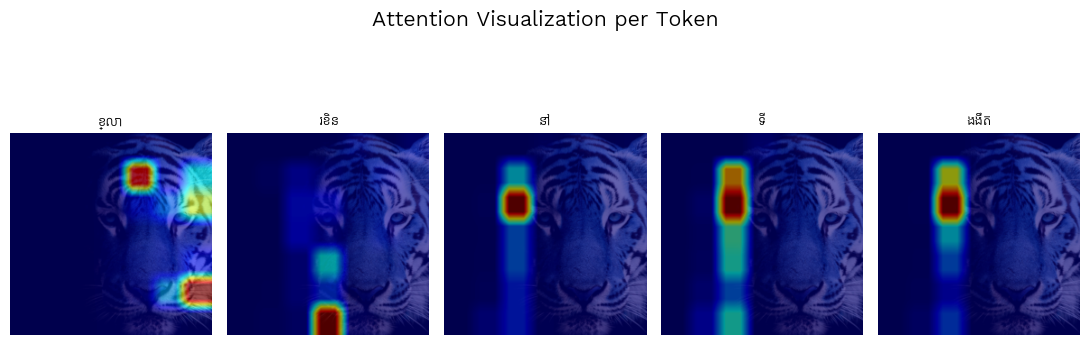

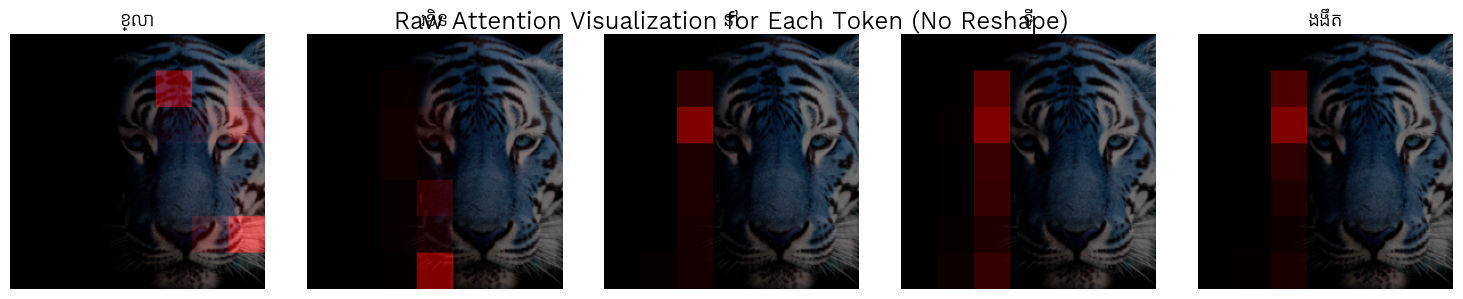

In [5]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import numpy as np

# Function to load idx2word and convert it to word2idx
def load_vocabulary(path):
    with open(path, 'r') as file:
        idx2word = json.load(file)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

# Load vocabulary
idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word_finalword_khmercut.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Attention Module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

class EncoderCNN(nn.Module):
    def __init__(self):
        super(EncoderCNN, self).__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        modules = list(resnet.children())[:-2]  # Keep conv feature map
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((14, 14))

    def forward(self, images):
        features = self.resnet(images)  # (B, 2048, H, W)
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1)  # (B, 14, 14, 2048)
        features = features.view(features.size(0), -1, features.size(-1))  # (B, 196, 2048)
        return features
    
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256, encoder_dim=2048, num_layers=1, dropout_prob=0.3):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)

    def forward(self, encoder_out, captions,states=None):
        batch_size = encoder_out.size(0)
        seq_len = captions.size(1)
        vocab_size = self.linear.out_features

        # Init hidden state and cell state
        h = self.init_h(encoder_out.mean(dim=1))  # (B, hidden_size)
        c = self.init_c(encoder_out.mean(dim=1))

        outputs = torch.zeros(batch_size, seq_len - 1, vocab_size).to(encoder_out.device)

        for t in range(seq_len - 1):
            embeddings = self.dropout(self.embed(captions[:, t]))  # (B, embed_size)
            context, _ = self.attention(encoder_out, h)            # (B, encoder_dim)
            lstm_input = torch.cat([embeddings, context], dim=1)   # (B, embed + encoder_dim)
            h, c = self.lstm(lstm_input, (h, c))                   # LSTMCell
            output = self.linear(self.dropout(h))                 # (B, vocab_size)
            outputs[:, t, :] = output

        return outputs,states

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize models
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx), num_layers=1,dropout_prob=0.3).to(device)

# Load model weights
encoder.load_state_dict(torch.load('encoder_finalv1_att_word.pth'))
decoder.load_state_dict(torch.load('decoder_finalv1_att_word.pth'))
encoder.eval()
decoder.eval()

# Beam Search Decoder
def beam_search_decoder(predictions, k):
    sequences = [[list(), 1.0]]  # list of (sequence, score)
    for row in predictions:
        all_candidates = list()
        for i in range(len(sequences)):
            seq, score = sequences[i]
            for j in range(len(row)):
                candidate = [seq + [j], score * -np.log(row[j])]
                all_candidates.append(candidate)
        # order all candidates by score
        ordered = sorted(all_candidates, key=lambda tup: tup[1])
        # select k best
        sequences = ordered[:k]
    return sequences

import cv2
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate_cam(self, index=0):
        grads = self.gradients[index]        # (C, H, W)
        acts = self.activations[index]       # (C, H, W)
        weights = grads.mean(dim=(1, 2))     # (C)
        cam = torch.zeros(acts.shape[1:], dtype=torch.float32).to(acts.device)

        for i, w in enumerate(weights):
            cam += w * acts[i]

        cam = torch.relu(cam)
        cam -= cam.min()
        cam /= cam.max()
        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        return cam

def overlay_heatmap(img_tensor, cam, alpha=0.5):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    overlayed = heatmap * alpha + img
    overlayed = np.clip(overlayed, 0, 1)
    plt.imshow(overlayed)
    plt.axis('off')
    plt.show()


def generate_caption_with_attention(image_path, encoder, decoder, idx2word, word2idx, transform, max_len=20):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)
    input_img = transform(image).cpu()

    encoder_out = encoder(image_tensor)
    h = decoder.init_h(encoder_out.mean(dim=1))
    c = decoder.init_c(encoder_out.mean(dim=1))

    seq = [word2idx['<START>']]
    caption = []
    attention_maps = []

    for _ in range(max_len):
        last_token = torch.tensor([seq[-1]]).to(device)
        embedding = decoder.embed(last_token)
        context, alpha = decoder.attention(encoder_out, h)
        lstm_input = torch.cat([embedding, context], dim=1)
        h, c = decoder.lstm(lstm_input, (h, c))
        output = decoder.linear(h)
        predicted = output.argmax(1).item()

        if predicted == word2idx['<END>']:
            break

        seq.append(predicted)
        caption.append(idx2word[str(predicted)])
        attention_maps.append(alpha.squeeze(0).detach().cpu().view(14, 14).numpy())

    return caption, attention_maps, input_img

import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

# 👉 Paste your Khmer font path here
khmer_font_path = "/home/vitoupro/code/image_captioning/data/KantumruyPro-VariableFont_wght.ttf"
prop = fm.FontProperties(fname=khmer_font_path)

def visualize_token_attention(caption, attention_maps, input_img, font_path):
    import matplotlib.pyplot as plt
    from matplotlib import font_manager as fm
    import cv2
    import numpy as np

    prop = fm.FontProperties(fname=font_path)

    # Normalize and resize input image to 224x224
    img = input_img.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    img = (img * 255).astype(np.uint8)
    img = cv2.resize(img, (224, 224))

    num_tokens = len(caption)
    fig, axes = plt.subplots(1, num_tokens, figsize=(num_tokens * 2.2, 4))

    if num_tokens == 1:
        axes = [axes]  # Ensure iterable

    for i, (token, attn) in enumerate(zip(caption, attention_maps)):
        attn_resized = cv2.resize(attn, (224, 224))
        attn_resized = (attn_resized - attn_resized.min()) / (attn_resized.max() - attn_resized.min() + 1e-8)
        attn_colored = cv2.applyColorMap(np.uint8(255 * attn_resized), cv2.COLORMAP_JET)

        overlay = cv2.addWeighted(attn_colored, 0.6, img, 0.4, 0)
        overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

        axes[i].imshow(overlay)
        axes[i].set_title(token, fontsize=14, fontproperties=prop)
        axes[i].axis("off")

    plt.suptitle("Attention Visualization per Token", fontproperties=prop, fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.8)  # Adjust to fit the suptitle

    # Optional: save to file
    # plt.savefig("caption_attention_khmer.png", dpi=300)

    plt.show()
    
import matplotlib.pyplot as plt

def visualize_raw_attention_all_tokens(attention_maps, input_img, caption, font_path=None):
    if font_path:
        prop = fm.FontProperties(fname=font_path)
    else:
        prop = None

    # Prepare the image
    img = input_img.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    img = (img * 255).astype(np.uint8)
    img = cv2.resize(img, (224, 224))

    h_feat, w_feat = 14, 14  # Grid dimensions
    patch_h = img.shape[0] // h_feat
    patch_w = img.shape[1] // w_feat

    num_tokens = len(caption)
    cols = 5
    rows = int(np.ceil(num_tokens / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()

    for i, (attn_weights, token) in enumerate(zip(attention_maps, caption)):
        attn_weights = attn_weights.flatten()
        attn_weights = attn_weights - attn_weights.min()
        attn_weights = attn_weights / (attn_weights.max() + 1e-8)

        heat_img = img.copy()
        for idx, weight in enumerate(attn_weights):
            y = idx // w_feat
            x = idx % w_feat

            top_left = (x * patch_w, y * patch_h)
            bottom_right = ((x + 1) * patch_w, (y + 1) * patch_h)

            color = (0, 0, int(255 * weight))  # Blue channel for heat
            cv2.rectangle(heat_img, top_left, bottom_right, color, thickness=-1)

        blended = cv2.addWeighted(heat_img, 0.5, img, 0.5, 0)
        blended = cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

        axes[i].imshow(blended)
        axes[i].set_title(token, fontproperties=prop, fontsize=14)
        axes[i].axis("off")

    # Remove empty subplots if any
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Raw Attention Visualization for Each Token (No Reshape)", fontproperties=prop, fontsize=18)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()



# Transformations
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

# Image path
# Your image path
image_path = "/home/vitoupro/code/image_captioning/data/11.png"

# Run caption + attention
caption, attention_maps, input_img = generate_caption_with_attention(
    image_path, encoder, decoder, idx2word, word2idx, transform
)

# Print caption
print("Generated Caption:", ''.join(caption))

# Visualize
visualize_token_attention(caption, attention_maps, input_img,khmer_font_path)
# Example for one token
token_index = 0  # Choose the index of token you want to visualize
attn_weights = attention_maps[token_index].flatten()  # Raw (196,) vector

# After generating caption, attention_maps, and input_img
visualize_raw_attention_all_tokens(attention_maps, input_img, caption, font_path=khmer_font_path)





/home/vitoupro/code/image_captioning/image_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vitoupro/code/image_captioning/image_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/vitoupro/code/image_captioning/image_env/lib/python3.12/site-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Ple

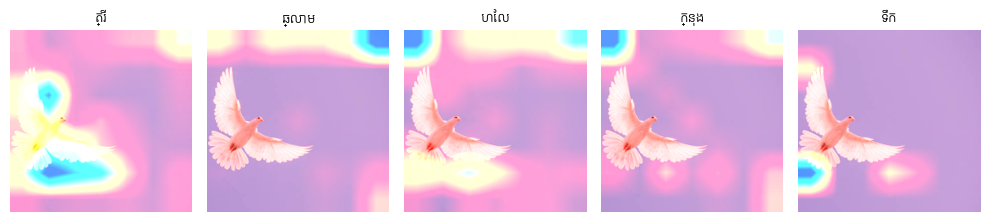

Generated Caption: ត្រីឆ្លាមហែលក្នុងទឹក


In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib import font_manager as fm


# Load idx2word and word2idx
def load_vocabulary(path):
    with open(path, 'r') as f:
        idx2word = json.load(f)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word_finalword_khmercut.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Attention module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

# Encoder
class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])
        self.adaptive_pool = nn.AdaptiveAvgPool2d((14, 14))

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))
        return features

# Decoder
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256, encoder_dim=2048):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.dropout = nn.Dropout(0.3)

    def forward_step(self, encoder_out, last_token, h, c):
        embedded = self.dropout(self.embed(last_token))
        context, _ = self.attention(encoder_out, h)
        lstm_input = torch.cat([embedded, context], dim=1)
        h, c = self.lstm(lstm_input, (h, c))
        output = self.linear(h)
        return output, h, c

# GradCAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self):
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam).squeeze()
        cam -= cam.min()
        cam /= cam.max()
        return cam.detach().cpu().numpy()

def overlay_heatmap(img_tensor, cam):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    return np.clip(heatmap * 0.8 + img, 0, 1)

# Model & device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx)).to(device)
encoder.load_state_dict(torch.load('encoder_finalv1_att_word.pth'))
decoder.load_state_dict(torch.load('decoder_finalv1_att_word.pth'))
encoder.eval()
decoder.eval()
gradcam = GradCAM(encoder.resnet[-1], encoder.resnet[-1][-1])

# Generate caption and visualize Grad-CAM
def generate_caption_with_gradcam(image_path):
    image = Image.open(image_path).convert("RGB")
    tensor_img = transform(image).unsqueeze(0).to(device)
    img_for_display = transform(image).to(device)

    tensor_img.requires_grad = True
    encoder_out = encoder(tensor_img)
    h = decoder.init_h(encoder_out.mean(dim=1))
    c = decoder.init_c(encoder_out.mean(dim=1))

    seq = [word2idx['<START>']]
    tokens, heatmaps = [], []

    for _ in range(20):
        last_token = torch.tensor([seq[-1]]).to(device)
        output, h, c = decoder.forward_step(encoder_out, last_token, h, c)
        idx = output.argmax(1).item()
        if idx in [word2idx['<END>'], word2idx['<PAD>']]:
            break
        seq.append(idx)
        tokens.append(idx2word[str(idx)])

        # Backward pass for Grad-CAM
        encoder.zero_grad()
        decoder.zero_grad()
        output[0, idx].backward(retain_graph=True)
        cam = gradcam.generate_cam()
        heatmaps.append(overlay_heatmap(img_for_display, cam))
        
    khmer_font_path = "/home/vitoupro/code/image_captioning/data/KantumruyPro-VariableFont_wght.ttf"
    khmer_font = fm.FontProperties(fname=khmer_font_path)


    # Plot
    fig, axes = plt.subplots(1, len(tokens), figsize=(len(tokens) * 2, 3))
    if len(tokens) == 1:
        axes = [axes]
    for i, (token, heatmap) in enumerate(zip(tokens, heatmaps)):
        axes[i].imshow(heatmap)
        axes[i].set_title(token, fontsize=100,fontproperties=khmer_font)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

    return ''.join(tokens)

# Image path and transform
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
image_path = '/home/vitoupro/code/image_captioning/notebook/image.png'

# Run
caption = generate_caption_with_gradcam(image_path)
print("Generated Caption:", caption)


Generating caption with spotlight visualization...


AttributeError: 'numpy.ndarray' object has no attribute 'imshow'

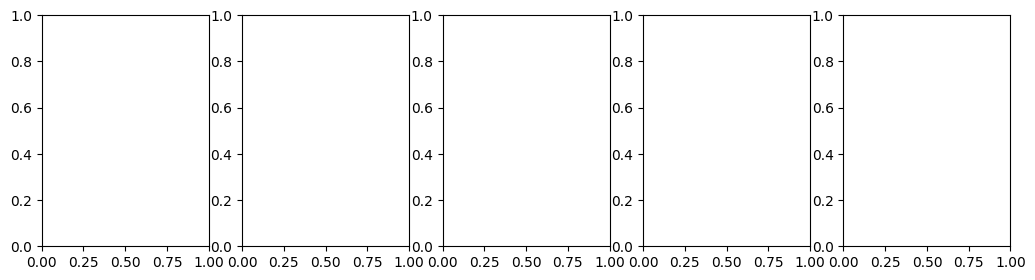

In [9]:
# Add spotlight visualization functionality
import cv2
import numpy as np
from matplotlib import font_manager as fm
import math

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json


# Load idx2word and word2idx
def load_vocabulary(path):
    with open(path, 'r') as f:
        idx2word = json.load(f)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word_finalword_khmercut.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Attention module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

# Encoder
class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])
        self.adaptive_pool = nn.AdaptiveAvgPool2d((14, 14))

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))
        return features

# Decoder
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256, encoder_dim=2048):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.dropout = nn.Dropout(0.3)

    def forward_step(self, encoder_out, last_token, h, c):
        embedded = self.dropout(self.embed(last_token))
        context, _ = self.attention(encoder_out, h)
        lstm_input = torch.cat([embedded, context], dim=1)
        h, c = self.lstm(lstm_input, (h, c))
        output = self.linear(h)
        return output, h, c

def create_soft_spotlight(img_tensor, attention_map):
    """Create a soft spotlight overlay using gray-to-white gradient"""
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    
    # Resize attention map to match image dimensions
    attention_resized = cv2.resize(attention_map, (img.shape[1], img.shape[0]))
    
    # Normalize attention to 0-1 range
    attention_norm = (attention_resized - attention_resized.min()) / (attention_resized.max() - attention_resized.min() + 1e-8)
    
    # Create spotlight effect: gray background with white highlights
    # Convert to grayscale first
    img_gray = np.dot(img, [0.299, 0.587, 0.114])
    img_gray = np.stack([img_gray] * 3, axis=-1)  # Convert back to 3-channel
    
    # Create spotlight mask: 0.3 (dark gray) to 1.0 (white)
    spotlight_intensity = 0.3 + 0.7 * attention_norm
    spotlight_mask = np.stack([spotlight_intensity] * 3, axis=-1)
    
    # Apply spotlight effect
    spotlighted_img = img_gray * spotlight_mask
    
    return np.clip(spotlighted_img, 0, 1)

def forward_step_with_attention(decoder, encoder_out, last_token, h, c):
    """Modified forward step to return attention weights"""
    embedded = decoder.dropout(decoder.embed(last_token))
    context, alpha = decoder.attention(encoder_out, h)
    lstm_input = torch.cat([embedded, context], dim=1)
    h, c = decoder.lstm(lstm_input, (h, c))
    output = decoder.linear(h)
    return output, h, c, alpha

def generate_caption_with_spotlight(image_path, encoder, decoder, word2idx, idx2word, transform, beam_size=5):
    """Generate caption using beam search and visualize attention with soft spotlight"""
    image = Image.open(image_path).convert("RGB")
    tensor_img = transform(image).unsqueeze(0).to(device)
    img_for_display = transform(image).to(device)
    encoder_out = encoder(tensor_img)

    k = beam_size
    vocab_size = len(word2idx)

    seqs = torch.LongTensor([[word2idx['<START>']]] * k).to(device)
    scores = torch.zeros(k, 1).to(device)
    complete_seqs, complete_scores, complete_spotlights = [], [], []
    h = decoder.init_h(encoder_out.mean(dim=1).expand(k, -1))
    c = decoder.init_c(encoder_out.mean(dim=1).expand(k, -1))
    encoder_out = encoder_out.expand(k, -1, -1)
    spotlight_list = [[] for _ in range(k)]

    for _ in range(40):
        last_words = seqs[:, -1]
        outputs, h, c, alpha = forward_step_with_attention(decoder, encoder_out, last_words, h, c)
        log_probs = torch.log_softmax(outputs, dim=1)
        scores_expanded = scores + log_probs
        scores_topk, topk_indices = scores_expanded.view(-1).topk(k, dim=0)

        prev_beam_indices = topk_indices // vocab_size
        next_word_indices = topk_indices % vocab_size

        seqs = torch.cat([seqs[prev_beam_indices], next_word_indices.unsqueeze(1)], dim=1)
        scores = scores_topk.unsqueeze(1)
        h = h[prev_beam_indices]
        c = c[prev_beam_indices]
        encoder_out = encoder_out[prev_beam_indices]
        alpha = alpha[prev_beam_indices]

        # Generate attention spotlight for top candidate
        with torch.no_grad():
            attention_map = alpha[0].view(14, 14).cpu().numpy()
            spotlight_img = create_soft_spotlight(img_for_display, attention_map)
            spotlight_list[0].append(spotlight_img)

        incomplete_inds = [i for i, next_word in enumerate(next_word_indices) if next_word != word2idx['<END>']]
        complete_inds = list(set(range(len(next_word_indices))) - set(incomplete_inds))

        if len(complete_inds) > 0:
            complete_seqs.extend(seqs[complete_inds].tolist())
            complete_scores.extend(scores[complete_inds])
            complete_spotlights.extend([spotlight_list[i] for i in complete_inds])
        k -= len(complete_inds)

        if k == 0:
            break

        seqs = seqs[incomplete_inds]
        scores = scores[incomplete_inds]
        h = h[incomplete_inds]
        c = c[incomplete_inds]
        encoder_out = encoder_out[incomplete_inds]
        spotlight_list = [spotlight_list[i] for i in incomplete_inds]

    best_seq_idx = complete_scores.index(max(complete_scores))
    best_seq = complete_seqs[best_seq_idx]
    best_spotlights = complete_spotlights[best_seq_idx]

    tokens = [idx2word[str(idx)] for idx in best_seq if idx not in [word2idx['<START>'], word2idx['<END>'], word2idx['<PAD>']]]

    # Visualize spotlight attention
    khmer_font_path = "/home/vitoupro/code/image_captioning/data/KantumruyPro-VariableFont_wght.ttf"
    try:
        khmer_font = fm.FontProperties(fname=khmer_font_path)
    except:
        khmer_font = None

    tokens_per_row = 5
    num_rows = math.ceil(len(tokens) / tokens_per_row)
    fig, axes = plt.subplots(num_rows, tokens_per_row, figsize=(tokens_per_row * 2.5, num_rows * 3))

    if num_rows == 1:
        axes = [axes] if tokens_per_row == 1 else axes
    else:
        axes = axes.flatten()

    for i in range(num_rows * tokens_per_row):
        ax = axes[i] if isinstance(axes, list) else axes
        if i < len(tokens):
            ax.imshow(best_spotlights[i])
            ax.set_title(tokens[i], fontsize=12, fontproperties=khmer_font)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return ''.join(tokens)

# Example usage of spotlight visualization
if __name__ == "__main__":
    # Load the trained models
    encoder.load_state_dict(torch.load('encoder_finalv1_att_word.pth'))
    decoder.load_state_dict(torch.load('decoder_finalv1_att_word.pth'))
    encoder.eval()
    decoder.eval()
    
    # Test image path
    test_image_path = '/home/vitoupro/code/image_captioning/data/00000001_020.jpg'
    
    print("Generating caption with spotlight visualization...")
    caption = generate_caption_with_spotlight(
        test_image_path, encoder, decoder, word2idx, idx2word, transform
    )
    print(f"Generated Caption: {caption}")